<a href="https://colab.research.google.com/github/Sebastian-Tamez/PDI_Laboratorio/blob/main/P5_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EJERCICIO 1**

Primero, se importan las librerías necesarias: OpenCV para el procesamiento de la imagen, NumPy para manejar matrices y Matplotlib para la visualización.

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Luego, se carga la imagen en escala de grises utilizando *cv2.imread*, lo que simplifica el procesamiento al trabajar con una sola intensidad por píxel. Después, se obtienen las dimensiones de la imagen (alto y ancho) a partir de su forma.

In [33]:
# Cargar la imagen en escala de grises
imagen = cv2.imread("UpperLegMRI.jpg", cv2.IMREAD_GRAYSCALE)

# Dimensiones de la imagen
alto, ancho = imagen.shape

A continuación, se define una matriz de traslación que desplaza la imagen 50 píxeles en el eje horizontal y 30 píxeles en el eje vertical. Esta matriz se construye en formato flotante y representa una transformación afín. Posteriormente, se aplica la transformación mediante la función *cv2.warpAffine*, que genera una nueva imagen desplazada.

In [34]:
# Definir la matriz de traslación (Mueve la imagen 50 px a la derecha y 30 px hacia abajo)
tx, ty = 50, 30  # Desplazamiento en X e Y
M = np.float32([[1, 0, tx], [0, 1, ty]])

# Aplicar la transformación afín
imagen_trasladada = cv2.warpAffine(imagen, M, (ancho, alto))

Finalmente, se muestran tanto la imagen original como la trasladada usando Matplotlib para comparar visualmente el efecto de la transformación.

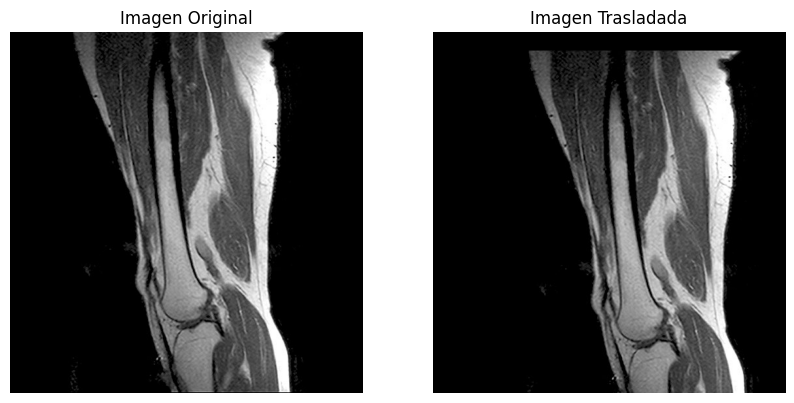

In [35]:
# Mostrar imágenes
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Imagen Trasladada")
plt.axis("off")

plt.show()

# **EJERCICIO 2**

En este ejercicio se sigue un proceso similar al anterior comenzando con la importación de librerías y la carga de la imagen en escala de grises. Se obtienen nuevamente sus dimensiones para mantener el tamaño de salida.

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [37]:
# Cargar la imagen en escala de grises
imagen = cv2.imread("UpperLegMRI.jpg", cv2.IMREAD_GRAYSCALE)

# Dimensiones de la imagen
alto, ancho = imagen.shape

La matriz de traslación utiliza valores decimales (20.5 en X y 15.5 en Y), lo que implica que los píxeles no caen exactamente en posiciones enteras. Debido a esto, al aplicar la transformación con *cv2.warpAffine*, se activa una interpolación lineal mediante el parámetro *flags=cv2.INTER_LINEAR*, lo que permite estimar valores intermedios de intensidad.

In [38]:
# Definir la matriz de traslación con valores decimales
tx, ty = 20.5, 15.5 # Desplazamiento en X e Y con decimales
M = np.float32([[1, 0, tx], [0, 1, ty]])

# Aplicar la traslación con interpolación
imagen_trasladada = cv2.warpAffine(imagen, M, (ancho, alto), flags=cv2.INTER_LINEAR)

Se produce una imagen más suave en comparación con una traslación entera. Finalmente, se muestran ambas imágenes para observar cómo la interpolación influye en el resultado.

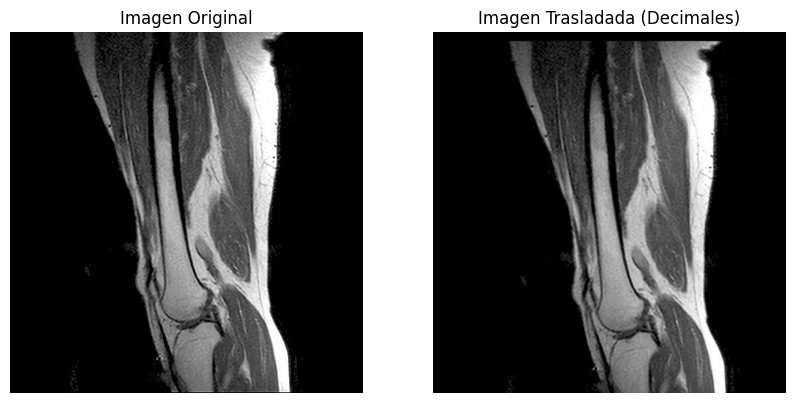

In [39]:
# Mostrar imágenes
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Imagen Trasladada (Decimales)")
plt.axis("off")

plt.show()

# **EJERCICIO 3**

El procedimiento inicia cargando la imagen y obteniendo sus dimensiones.

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [41]:
# Cargar la imagen en escala de grises
imagen = cv2.imread("UpperLegMRI.jpg", cv2.IMREAD_GRAYSCALE)

# Dimensiones de la imagen
alto, ancho = imagen.shape

Posteriormente, se aplica una traslación utilizando una matriz afín que desplaza la imagen 50 píxeles en X y 30 en Y. Sobre la imagen ya trasladada, se define una transformación de rotación especificando un ángulo de 50 grados y el centro de la imagen como punto de giro. Esta matriz se obtiene con la función *cv2.getRotationMatrix2D*, que también permite mantener la escala original (en este caso, escala igual a 1). Luego, se aplica la rotación mediante *cv2.warpAffine*.

In [42]:
# Definir traslación (50 píxeles en X, 30 píxeles en Y)
tx, ty = 50, 30
M_translacion = np.float32([[1, 0, tx], [0, 1, ty]])

# Aplicar traslación
imagen_trasladada = cv2.warpAffine(imagen, M_translacion, (ancho, alto))

In [43]:
# Definir rotación (30° alrededor del centro de la imagen)
angulo = 50
centro = (ancho // 2, alto // 2)  # Centro de la imagen
escala = 1.0  # Sin cambios en el tamaño

M_rotacion = cv2.getRotationMatrix2D(centro, angulo, escala)

# Aplicar rotación sobre la imagen trasladada
imagen_final = cv2.warpAffine(imagen_trasladada, M_rotacion, (ancho, alto))

Finalmente, se muestran la imagen original, la trasladada y la transformada final para comparar cada etapa del proceso.

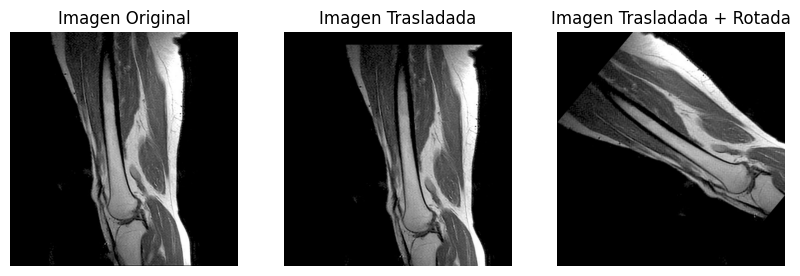

In [44]:
# Mostrar imágenes
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Imagen Trasladada")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagen_final, cmap="gray")
plt.title("Imagen Trasladada + Rotada")
plt.axis("off")

plt.show()

# **EJERCICIO 4**

Primero, se carga la imagen y se realiza una traslación de 50 píxeles en X y 30 en Y

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# Cargar la imagen en escala de grises
imagen = cv2.imread("UpperLegMRI.jpg", cv2.IMREAD_GRAYSCALE)

# Dimensiones de la imagen
alto, ancho = imagen.shape

In [47]:
# Definir traslación (50 píxeles en X, 30 píxeles en Y)
tx, ty = 50, 30
M_translacion = np.float32([[1, 0, tx], [0, 1, ty]])

# Aplicar traslación
imagen_trasladada = cv2.warpAffine(imagen, M_translacion, (ancho, alto))

Después, se define el centro de la imagen como referencia para las transformaciones posteriores. Se generan dos matrices de transformación usando *cv2.getRotationMatrix2D*, donde además de la rotación (50 grados), se incluye un factor de escala: uno de 0.5 (reducción al 50%) y otro de 1.5 (aumento al 150%). Estas matrices se aplican a la imagen trasladada mediante *cv2.warpAffine*, produciendo dos versiones distintas: una más pequeña y otra ampliada.

In [48]:
# Definir rotación + escalado (30° alrededor del centro con 0.8 de escala)
angulo = 50
centro = (ancho // 2, alto // 2)  # Centro de la imagen

# Escala 50%
M_escala_50 = cv2.getRotationMatrix2D(centro, angulo, 0.5)
imagen_50 = cv2.warpAffine(imagen_trasladada, M_escala_50, (ancho, alto))

# Escala 150%
M_escala_150 = cv2.getRotationMatrix2D(centro, angulo, 1.5)
imagen_150 = cv2.warpAffine(imagen_trasladada, M_escala_150, (ancho, alto))

Finalmente, se muestran la imagen original, la trasladada y ambas versiones escaladas para observar claramente el efecto del cambio de tamaño combinado con la rotación.

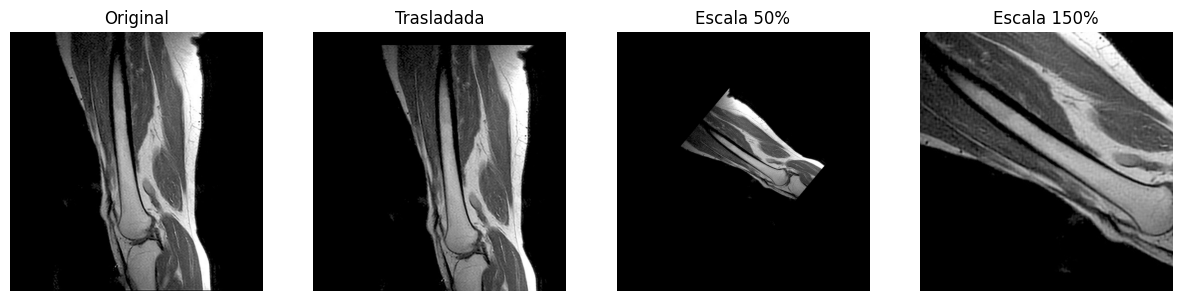

In [49]:
# Mostrar imágenes
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Trasladada")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(imagen_50, cmap="gray")
plt.title("Escala 50%")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(imagen_150, cmap="gray")
plt.title("Escala 150%")
plt.axis("off")

plt.show()

# **EJERCICIO 5**

En la primera parte, se carga la imagen y se definen tres puntos de referencia originales y sus correspondientes puntos transformados. Estos puntos permiten calcular una matriz de transformación afín utilizando *cv2.getAffineTransform*, la cual describe cómo se deformará la imagen. Posteriormente, se aplica esta transformación con *cv2.warpAffine*, obteniendo una imagen modificada en la que se observan cambios en posición, orientación y forma.

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# Cargar la imagen en escala de grises
imagen = cv2.imread("UpperLegMRI.jpg", cv2.IMREAD_GRAYSCALE)

In [52]:
# Definir puntos originales (antes de la transformación)
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])

# Definir nuevos puntos transformados
pts2 = np.float32([[10, 10], [200, 100], [10, 250]])

# Obtener la matriz de transformación afín
M = cv2.getAffineTransform(pts1, pts2)

# Aplicar la transformación
filas, columnas = imagen.shape
imagen_transformada = cv2.warpAffine(imagen, M, (columnas, filas))

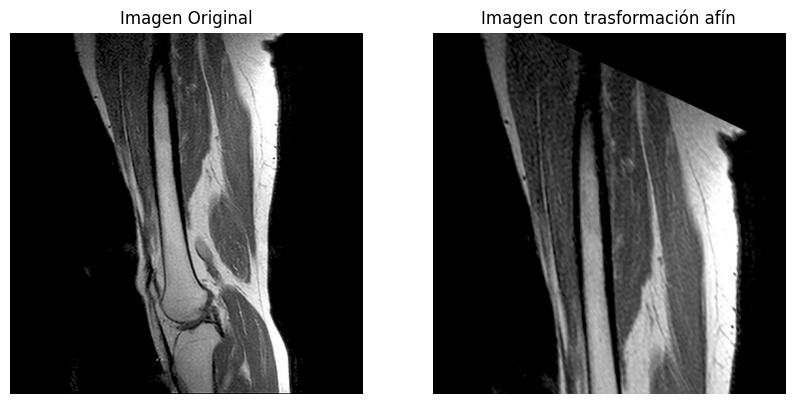

In [53]:
# Mostrar imágenes
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_transformada, cmap="gray")
plt.title("Imagen con trasformación afín")
plt.axis("off")

plt.show()

En la segunda parte, se aborda la distorsión radial utilizando parámetros simulados de calibración de cámara. Se define una matriz intrínseca y coeficientes de distorsión radial, los cuales modelan cómo se deforma la imagen debido a efectos ópticos como el “ojo de pez”. Luego, se utiliza la función *cv2.getOptimalNewCameraMatrix* para ajustar los parámetros y *cv2.undistort* para corregir o aplicar la distorsión. Finalmente, se muestran las imágenes original y corregida para comparar el efecto de la distorsión radial sobre la imagen.

In [54]:
# Matriz de calibración de la cámara y coeficientes de distorsión (valores de ejemplo)
K = np.array([[1000, 0, 640], [0, 1000, 360], [0, 0, 1]])  # Matriz intrínseca
dist_coef = np.array([-0.2, 0.05, 0, 0, 0])  # Coeficientes de distorsión radial

# Corregir la distorsión radial
h, w = imagen.shape[:2]
new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist_coef, (w, h), 1, (w, h))
imagen_corregida = cv2.undistort(imagen, K, dist_coef, None, new_K)

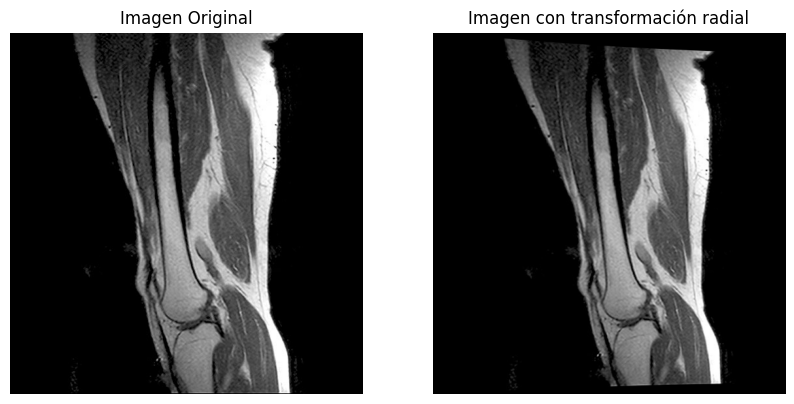

In [55]:
# Mostrar imágenes
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_corregida, cmap="gray")
plt.title("Imagen con transformación radial")
plt.axis("off")

plt.show()